In [ ]:
import pandas as pd
import numpy as np
df1 = pd.read_csv('checkpoint_results_so2.csv')
df2 = pd.read_csv('checkpoint_results_non.csv')
df3 = pd.read_csv('checkpoint_results_SO2_replace1.csv')
df4 = pd.read_csv('checkpoint_results_half.csv')
all_results_half = np.load('all_results_half.npy')
all_results_non = np.load('all_results_non.npy')
all_results_replace = np.load('all_results_replace.npy')
all_results_so2 = np.load('all_results_so2.npy')

In [ ]:
def freturn_performance(all_results):
    final_angles = [results[:, 1] for results in all_results]
    maxdeg =10
    maxrad = np.deg2rad(maxdeg)
    succes_rate = [len(results[:, 1][results[:, 1] < maxrad])/len(results[:, 1]) for results in all_results]
    return succes_rate


def plot_learn(filename = "./evals/evaluations.npz", label = " ", color='blue', ax = plt, scale = 1):
    data = np.load(filename)

    timesteps = data['timesteps']      # evaluation timestep
    rewards = data['results']          # cumulative reward for each eval
    lengths = data['ep_lengths']       # episode length
    episodes = range(1, len(rewards)+1)

    mean_rewards = rewards.mean(axis=1)
    std_rewards = rewards.std(axis=1)

    ax.fill_between(timesteps/scale, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.5, color=color)
    ax.plot(timesteps/scale, mean_rewards, 'r-.', label=label, color=color)

In [12]:
mean_final1 = df1['mean_final']
mean_final2 = df2['mean_final']
mean_final3 = df3['mean_final']
mean_final4 = df4['mean_final']

std_final1 = df1['std_final']
std_final2 = df2['std_final']
std_final3 = df3['std_final']
std_final4 = df4['std_final']

rad_to_deg = 180/np.pi

/tmp/ipykernel_1247460/3310245205.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-." (-> color='r'). The keyword argument will take precedence.
  ax.plot(timesteps/scale, mean_rewards, 'r-.', label=label, color=color)


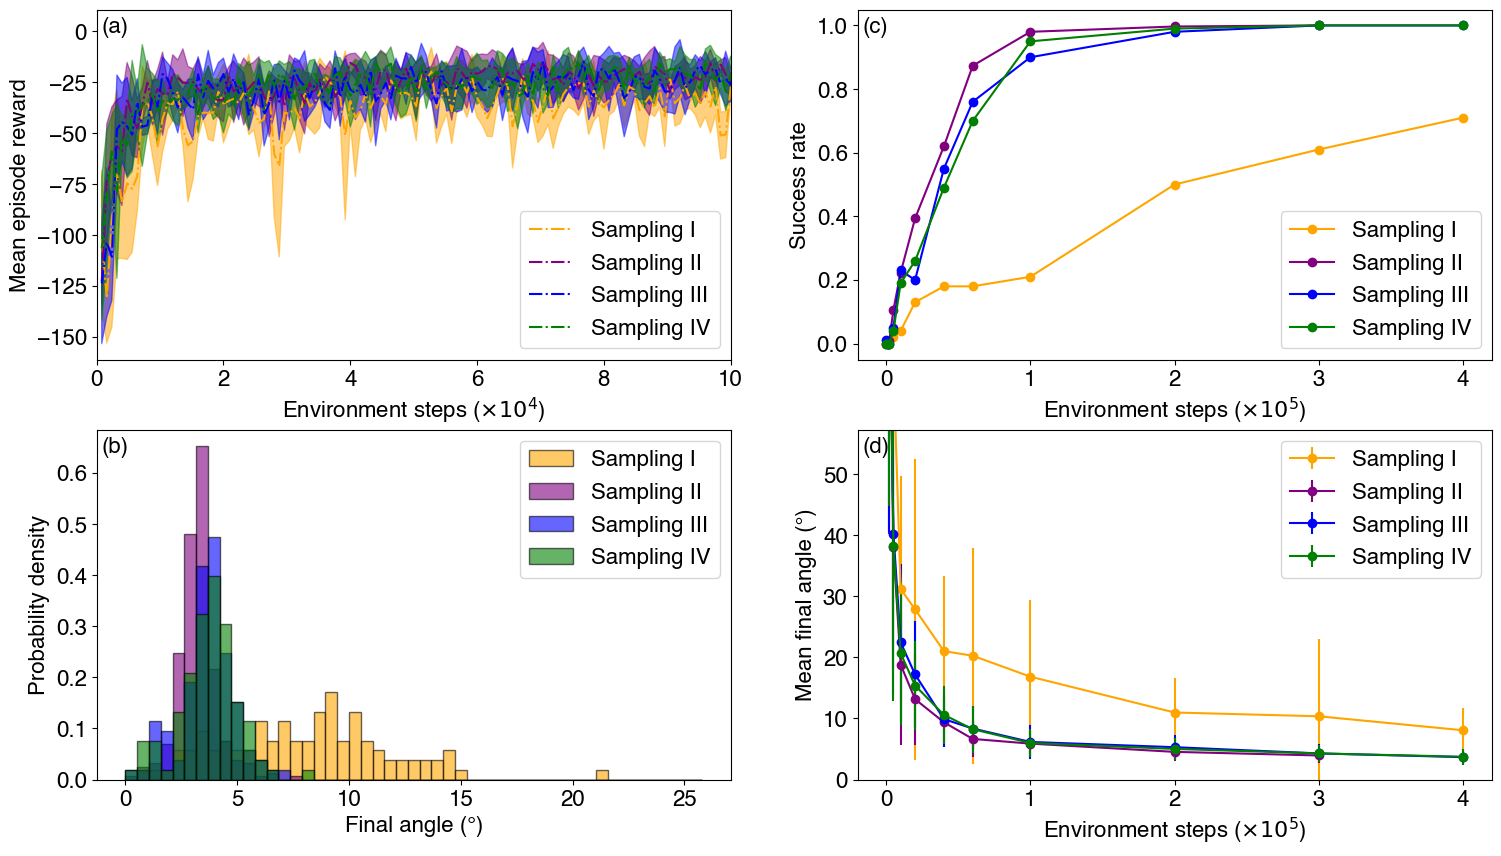

In [ ]:
import matplotlib.pyplot as plt

sl = freturn_performance(all_results_non)
sl2 = freturn_performance(all_results_replace)
sl3 = freturn_performance(all_results_so2)
sl4 = freturn_performance(all_results_half)


import matplotlib.pyplot as plt
from matplotlib import font_manager
font_manager.fontManager.addfont("/home/tilen/.local/share/fonts/Helvetica.ttf")

fig, ax = plt.subplots(2, 2, figsize=(18, 10))

plt.rcParams.update({'font.size':16, 'axes.labelsize': 16})
plt.rcParams['font.family'] = 'Helvetica'

ax[0, 1].plot(df2['step']/100000, sl, marker='o', color='orange', label='Sampling I')
ax[0, 1].plot(df3['step'][:-2]/100000, sl2[:-2], marker='o', color='purple', label='Sampling II')
ax[0, 1].plot(df1['step']/100000, sl3, marker='o', color='blue', label='Sampling III')
ax[0, 1].plot(df4['step']/100000, sl4, marker='o', color='green', label='Sampling IV')
ax[0, 1].set_xticks([0, 1, 2, 3, 4])
ax[0, 1].set_xlabel('Environment steps ($\\times 10^5$)')
ax[0, 1].set_ylabel('Success rate')
ax[0, 1].legend()

plot_learn("./evals/evaluations_non.npz", label="Sampling I", color='orange', ax=ax[0, 0], scale = 10000)
plot_learn("./evals/evaluations_so2_rep.npz", label="Sampling II", color='purple', ax=ax[0, 0], scale = 10000)
plot_learn("./evals/evaluations_so2.npz", label="Sampling III", color='blue', ax=ax[0, 0], scale = 10000)
plot_learn("./evals/evaluations_half.npz", label="Sampling IV", color='green', ax=ax[0, 0], scale = 10000)
ax[0, 0].set_xlim(0,10)
ax[0, 0].set_xticks([0, 2, 4, 6, 8, 10])
ax[0, 0].set_xlabel('Environment steps ($\\times 10^4$)')
ax[0, 0].set_ylabel('Mean episode reward')
ax[0, 0].legend()

rad_to_deg = 180/np.pi
bins = np.linspace(0, 0.45*rad_to_deg, 50)
step = 11
ax[1,0].hist(all_results_non[step][:, 1]*rad_to_deg, bins=bins, ec = 'black', density=True, color='orange', alpha=0.6, label='Sampling I')
ax[1,0].hist(all_results_replace[step][:, 1]*rad_to_deg, bins=bins, ec = 'black', density=True, color='purple', alpha=0.6, label='Sampling II')
ax[1,0].hist(all_results_so2[step][:, 1]*rad_to_deg, bins=bins, ec = 'black', density=True, color='blue', alpha=0.6, label='Sampling III')
ax[1,0].hist(all_results_half[step][:, 1]*rad_to_deg, bins=bins, ec = 'black', density=True, color='green', alpha=0.6, label='Sampling IV')
ax[1,0].legend()
ax[1,0].set_xlabel("Final angle (°)")
ax[1,0].set_ylabel("Probability density")

ax[1,1].errorbar(df2['step']/100000, mean_final2*rad_to_deg, yerr=std_final2*rad_to_deg, label='Sampling I', color='orange', fmt='-o')
ax[1,1].errorbar(df3['step'][:-2]/100000, mean_final3[:-2]*rad_to_deg, yerr=std_final3[:-2]*rad_to_deg, label='Sampling II', color='purple', fmt='-o')
ax[1,1].errorbar(df1['step']/100000, mean_final1*rad_to_deg, yerr=std_final1*rad_to_deg, label='Sampling III', color='blue', fmt='-o')
ax[1,1].errorbar(df4['step']/100000, mean_final4*rad_to_deg, yerr=std_final4*rad_to_deg, label='Sampling IV', color='green', fmt='-o')

ax[1,1].set_xticks([0, 1, 2, 3, 4])
ax[1,1].set_ylabel('Mean final angle (°)')
ax[1,1].set_xlabel('Environment steps ($\\times 10^5$)') 
ax[1,1].legend()
ax[1,1].set_ylim(0,1*rad_to_deg)

ax[0, 0].text(
    0.0075, 0.98, '(a)',
    transform=ax[0, 0].transAxes,
    ha='left', va='top',
    fontweight='bold',
    fontsize=16
)

ax[1, 0].text(
    0.0075, 0.98, '(b)',
    transform=ax[1, 0].transAxes,
    ha='left', va='top',
    fontweight='bold',
    fontsize=16
)

ax[0, 1].text(
    0.0075, 0.98, '(c)',
    transform=ax[0, 1].transAxes,
    ha='left', va='top',
    fontweight='bold',
    fontsize=16
)

ax[1, 1].text(
    0.0075, 0.98, '(d)',
    transform=ax[1, 1].transAxes,
    ha='left', va='top',
    fontweight='bold',
    fontsize=16
)

plt.savefig('success_rate_comparison.png', dpi=300, bbox_inches="tight")